# PokeOracle: Multi-model AI for Biological Identiication and Strategic Battle Simulation

# Environment Setup: Installing high-performance dependencies and Unsloth libraries for Gemma-4 Vision."



In [1]:
%%capture
try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
except: _numpy = "numpy"; _pil = "pillow"
!uv pip install -qqq \
    "torch>=2.8.0" "triton>=3.4.0" {_numpy} {_pil} torchvision bitsandbytes \
    unsloth "unsloth_zoo>=2026.4.6" transformers==5.5.0 torchcodec timm


# Model Loading: Initializing the Gemma-4-E2B-it model with 4-bit quantization for memory efficiency.

In [2]:
from unsloth import FastModel

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
import torch 

model , tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-4-E2B-it",
    dtype = None,
    max_seq_length = 2048,
    load_in_4bit = True,
    full_finetuning = False,
)

==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

# Pipeline Configuration: Setting up the text generation pipeline for deterministic and efficient inference using bfloat16.

In [4]:
from transformers import pipeline

pipe = pipeline(
    "text-generation",
    model = model,
    tokenizer = tokenizer,
    return_full_text  = False,
    max_new_tokens = 500,
    do_sample = False,
    torch_dtype = torch.bfloat16
)

`torch_dtype` is deprecated! Use `dtype` instead!
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


# Pokédex Inference Function: Implementing a visual analysis pipeline to generate structured biological profiles for Pokémon using Vision-Language processing.


=========================📱 POKÉDEX SCAN ==============================


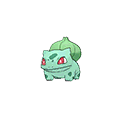


🧬 --------------------------------------------------
📋 DATA RETRIEVED:
╔=================================================================╗
║ Greetings! I am Professor Elm, and I have had the distinct pleasure of studying the myriad wonders of the Pokémon world. I have carefully examined this image, and I can offer you a detailed biological profile of this fascinating creature. ║
║ easure of studying the myriad wonders of the Pokémon world. I have carefully examined this image, and I can offer you a detailed biological profile of this fascinating creature. ║
║  have carefully examined this image, and I can offer you a detailed biological profile of this fascinating creature. ║
║ tailed biological profile of this fascinating creature.       ║
║                                                               ║
║                                                               ║
║ 🌿 Pokémon Biological Profile 🌿                                ║
║                                                 

In [5]:
import torch
from PIL import Image 
import os 
from transformers import TextStreamer
from IPython.display import display , Image as IPImage 

POKEMON_IMG_DIR = "/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images" 

def poke_vision_inference(pokemon_name_or_id , max_tokens = 500):
    img_path = f"{POKEMON_IMG_DIR}/{pokemon_name_or_id}.png"
    if not os.path.exists(img_path):
        img_path = img_path.replace(".png",'.jpg')

    if os.path.exists(img_path):
        print(f"\n" + '='*25 + "📱 POKÉDEX SCAN " + "="*30) 
        display(IPImage(filename = img_path , width = 280)) 
    messages = [
        {'role': 'user',"content":[
            {
                "type": "text",
                "text": (
                    "Act as an expert Pokemon Professor. Analyze this image and provide a detailed biological profile:"
                    "1) Official Name. "
                    "2) Type Combination. "
                    "3) Detailed Personality & Abilities: Describe its unique poers , how it uses its body in battel , and its typical temperament. " 
                    "4) Combat Readiness: Estmated CP and why it fits its current evolutionary stage. "
                    "Be descriptive and engaging like a true Pokedex entry."
                ),
            },
            {'type': "image", "image": img_path} 
        ]}
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True,
        tokenize = True,
        return_dict = True,
        return_tensors = "pt",
    ).to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens= max_tokens,
        use_cache = True,
        temperature = 0.7,
        top_p = 0.9

        
    )
    full_text = tokenizer.decode(outputs[0], skip_special_tokens = True) 
    response = full_text.split("model\n")[-1] if "model\n" in full_text else full_text
    if "thought" in response: response = response.split("thought")[-1]
        

    print("\n" + "🧬 " + '-' * 50)
    print("📋 DATA RETRIEVED:")
    lines = response.strip().split('\n') 
    print("╔"+ "=" * 65 + "╗")
    for line in lines:
        if line.strip():
            clean_line = line.replace("*","").replace("#", "").strip() 
            for i in range(0 , len(clean_line), 61):
                chunk = clean_line[i:i+611]
                print(f"║ {chunk:<61} ║")
        else:
            print(f"║ {' ':<61} ║")
    print("╚" + "="* 65 + "╝")
    print("-" * 63 + "✅ ANALYSIS COMPLETE\n")
poke_vision_inference("bulbasaur")

# Simplified Vision Inference: A lightweight function for quick Pokémon identification, focusing on essential data like Name, Type, and Abilities.

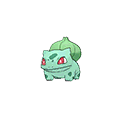


╔══════════════════════════════════════════╗
╠==========================================╣
║ Name: Gastly                             ║
║ Type: Ghost                              ║
║ Abilities: Levitate, Infiltrator         ║
╚==========================================╝


In [6]:
def poke_vision_simple(pokemon_name_or_id):
    img_path = f"{POKEMON_IMG_DIR}/{pokemon_name_or_id}.png" 
    if not os.path.exists(img_path):
        img_path = img_path.replace(".png",".jpg") 

        return

    display(IPImage(filename = img_path , width = 200))

    messages = [
        {'role': 'user','content':[
            {'type': 'text', 'text': "Identify this Pokemon. Provide Name, Type, and 2 main abilities. Be very brief and do not show your thoughts."},
            {'type':"image","image":img_path} 

            
        ]}
    ]
    inputs = tokenizer.apply_chat_template(messages , add_generation_prompt = True, tokenize = True , return_dict = True , return_tensors = 'pt').to('cuda')
    outputs = model.generate(**inputs , max_new_tokens = 150 , temperature = 0.2) 

    response = tokenizer.decode(outputs[0], skip_special_tokens = True).split('model\n')[-1] 
    
    print("\n" + "╔" + "═" * 42 + "╗") 

    print("╠" + "=" * 42 + "╣") 



    for line in response.strip().split('\n'):

        if line.strip():

            clean_line = line.replace("*", "").strip() 

            print(f"║ {clean_line[:40]:<40} ║")

    print("╚" + "="*42 + "╝") 



poke_vision_simple("bulbasaur")

# Parameter-Efficient Fine-Tuning (PEFT): Configuring LoRA adapters to train language, attention, and MLP modules while freezing vision layers.

In [7]:
model = FastModel.get_peft_model(
    model , 
    finetune_vision_layers      = False,
    finetune_language_layers    = True,
    finetune_attention_modules  = True,
    finetune_mlp_modules        = False,

    r = 8,
    lora_alpha = 8,
    lora_dropout = 0,
    bias = 'none',
    random_state = 3407,

    
)

# "Data Acquisition: Loading the Pokémon dataset containing names, types, and metadata using Pandas."

In [8]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/pokemon.csv")

# Reasoning Logic: Implementing a structured 'Thinking Format' to simulate deep-scan protocols and evolutionary trajectory analysis."


In [9]:
import os 
def create_thinking_format(row):
    raw_name = row.get('Name')
    if pd.isna(raw_name) or raw_name == "":
        name = f"Unidentified-Specimen-{row.name}"
        is_predicted = True
    else:
        name = raw_name
        is_predicted = False

    t1 = row.get('Type1', 'Unknown')
    t2 = row.get('Type2') if pd.notna(row.get('Type2')) else "None"
    
    evo = row.get('Evolution')
    if pd.isna(evo) or evo == "":
        evolution_text = "Analysis suggests this is the pinnacle of its lineage (Final Form)."
        evo_answer = "Final Form"
    else:
        evolution_text = f"Biometric patterns align with a future evolution into {evo}."
        evo_answer = evo

    thought_process = (
        f"Starting deep-scan protocol... {'CAUTION: Identity lost in database. Analyzing elemental DNA...' if is_predicted else 'Target Identified: ' + name + '.'} "
        f"Elemental markers indicate a primary {t1} essence."
    )
    if t2 != "None":
        thought_process += f"Secondary {t2} traits confirmed. "

    thought_process += f"Evolutionary trajectory: {evolution_text}"

    final_answer = f"Name: {name}\nType: {t1}{' / ' + t2 if t2 != 'None' else ''}\nNext Stage: {evo_answer}"

    return thought_process , final_answer

# "Dataset Preparation: Constructing a multi-modal dataset by mapping images to their corresponding reasoning chains and structured outputs.

In [10]:
import os 
from datasets import Dataset

fromatted_data = [] 

for _, row in df.iterrows():
    pokemon_name = row.get("Name") 
    img_path = f"/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/{pokemon_name}.png" 

    if os.path.exists(img_path):
        thought , answer = create_thinking_format(row) 

        fromatted_data.append({
            "instruction": "Analyze this Pokemon image and provide a biological report.",
            "input": str(pokemon_name),
            "image": img_path,
            "thought": thought,
            "output": answer
        })

dataset = Dataset.from_list(fromatted_data)

# "Data Verification: Inspecting a sample record to ensure images, thought chains, and outputs are correctly mapped.

In [11]:
dataset[100]

{'instruction': 'Analyze this Pokemon image and provide a biological report.',
 'input': 'electrode',
 'image': '/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/electrode.png',
 'thought': 'Starting deep-scan protocol... Target Identified: electrode. Elemental markers indicate a primary Electric essence.Evolutionary trajectory: Analysis suggests this is the pinnacle of its lineage (Final Form).',
 'output': 'Name: electrode\nType: Electric\nNext Stage: Final Form'}

# "Chat Template Formatting: Applying the Gemma-4 thinking template and structuring data into a multi-turn conversational format (User/Thought/Model).

In [12]:
from unsloth.chat_templates import get_chat_template 

tokenizer = get_chat_template(
    tokenizer , 
    chat_template = "gemma-4-thinking"
)

def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    inputs       = examples['input']
    thoughts     = examples['thought'] 
    outputs      = examples['output'] 
    texts   = [] 

    for instruction, input, thought, output in zip(instructions, inputs, thoughts, outputs): 
        text = f"<bos><start_of_turn>user\n{instruction}\n{input}<end_of_turn>\n<start_of_turn>thought\n{thought}<end_of_turn>\n<start_of_turn>model\n{output}<end_of_turn><eos>" 

        texts.append(text)
    return {'text': texts, } 

dataset = dataset.map(formatting_prompts_func , batched = True)

Map:   0%|          | 0/809 [00:00<?, ? examples/s]

In [13]:
dataset[100]

{'instruction': 'Analyze this Pokemon image and provide a biological report.',
 'input': 'electrode',
 'image': '/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/electrode.png',
 'thought': 'Starting deep-scan protocol... Target Identified: electrode. Elemental markers indicate a primary Electric essence.Evolutionary trajectory: Analysis suggests this is the pinnacle of its lineage (Final Form).',
 'output': 'Name: electrode\nType: Electric\nNext Stage: Final Form',
 'text': '<bos><start_of_turn>user\nAnalyze this Pokemon image and provide a biological report.\nelectrode<end_of_turn>\n<start_of_turn>thought\nStarting deep-scan protocol... Target Identified: electrode. Elemental markers indicate a primary Electric essence.Evolutionary trajectory: Analysis suggests this is the pinnacle of its lineage (Final Form).<end_of_turn>\n<start_of_turn>model\nName: electrode\nType: Electric\nNext Stage: Final Form<end_of_turn><eos>'}

# "Template Initialization: Configuring the tokenizer with the Gemma-4 thinking template to enable structured chain-of-thought processing."

In [14]:
from unsloth.chat_templates import get_chat_template 
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma-4-thinking",
)

# "Memory Optimization: Enabling expandable segments in PyTorch to prevent memory fragmentation and optimize VRAM usage during training."

In [15]:
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# "Trainer Configuration: Initializing the SFTTrainer with optimized hyperparameters, memory management, and 8-bit AdamW optimization for efficient fine-tuning."

In [16]:
from trl import SFTTrainer, SFTConfig 
from unsloth import is_bfloat16_supported

import gc
gc.collect() 
torch.cuda.empty_cache()

trainer = SFTTrainer(
    model = model, 
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = 512,
    args = SFTConfig(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = 'adamw_8bit',
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        #fp16 = True,
        #bf16 = False,
        gradient_checkpointing = False,
        report_to = "none",
    ),
)

# "Selective Training: Configuring 'Train on Responses Only' to ensure the model computes loss only on the generated thought and output, ignoring the user instructions."

In [17]:
from unsloth.chat_templates import train_on_responses_only 

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<start_of_turn>user\n",
    response_part = "<start_of_turn>thought\n",
)

Map (num_proc=8):   0%|          | 0/809 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/809 [00:00<?, ? examples/s]

Filter (num_proc=8):   0%|          | 0/809 [00:00<?, ? examples/s]

# "Masking Verification: Visualizing the training sample to confirm that the model learns only from the 'Thought' and 'Response' sections while masking the input prompt."


🔍 ======================================================================
║ TRAINING SAMPLE: #100


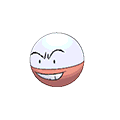


🟦 [INPUT - What the model sees]:
----------------------------------------
<bos><start_of_turn>user
Analyze this Pokemon image and provide a biological report.
electrode<end_of_turn>
<start_of_turn>thought
Starting deep-scan protocol... Target Identified: electrode. Elemental markers indicate a primary Electric essence.Evolutionary trajectory: Analysis suggests this is the pinnacle of its lineage (Final Form).<end_of_turn>
<start_of_turn>model
Name: electrode
Type: Electric
Next Stage: Final Form<end_of_turn><eos>

🟩 [LABELS - What the model actually learns (Loss Calculation)]:
----------------------------------------
Starting deep-scan protocol... Target Identified: electrode. Elemental markers indicate a primary Electric essence.Evolutionary trajectory: Analysis suggests this is the pinnacle of its lineage (Final Form).<end_of_turn>
<start_of_turn>model
Name: electrode
Type: Electric
Next Stage: Final Form<end_of_turn><eos>

===========================================================

In [18]:
from IPython.display import display , Image as IPImage 

sample_index = 100
sample = trainer.train_dataset[sample_index] 

input_text = tokenizer.decode(sample['input_ids'], skip_special_tokens = False) 

labels = [tokenizer.pad_token_id if x == -100 else x for x in sample['labels']] 

label_text = tokenizer.decode(labels, skip_special_tokens = False).replace(tokenizer.pad_token, "")

print("\n" + "🔍 " + "="*70) 
print(f"║ TRAINING SAMPLE: #{sample_index}") 
print('='*72) 

if os.path.exists(sample['image']):
    display(IPImage(filename=sample['image'] , width = 200)) 

print('\n' + "🟦 [INPUT - What the model sees]:") 
print('-' * 40) 
print(input_text) 

print('\n' + "🟩 [LABELS - What the model actually learns (Loss Calculation)]:") 
print("-"* 40) 

if label_text.strip() == "":
    print(" (Masked/Empty - Good! Model is not trained on this part)") 
else:
    print(label_text)

print("\n" + '='*72 + " ✅")

# "Hardware Assessment: Auditing GPU specifications and monitoring VRAM allocation to ensure sufficient memory overhead for the training process."

In [19]:
import torch

gpu_stats = torch.cuda.get_device_properties(0)

start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)


max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)

print(f"GPU: {gpu_stats.name} | Total Memory: {max_memory} GB")

print(f"Reserved Memory: {start_gpu_memory} GB")

print(f"Free Memory: {max_memory - start_gpu_memory} GB")


GPU: Tesla T4 | Total Memory: 14.563 GB
Reserved Memory: 7.988 GB
Free Memory: 6.575 GB


# "Model Training: Executing the supervised fine-tuning process and capturing training statistics."

In [20]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 809 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 12,668,928 of 5,135,846,944 (0.25% trained)
Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Step,Training Loss
1,17.649876
2,16.686953
3,17.018738
4,17.150429
5,17.140484
6,17.298660
7,16.742493
8,16.242264
9,15.177823
10,12.270025


# "Battle Simulator: Implementing a multi-image inference pipeline to simulate dynamic Pokémon battles based on visual analysis and elemental stats."


---⚡ Les't Battle ⚡---
[ARCANINE]  VS  [HONCHKROW]


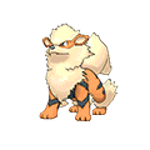

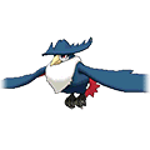


Based on the images provided, here is the analysis and hypothetical battle scenario:

**Image Analysis:**

1.  **First Image:** Shows a Pokémon that strongly resembles **Arcanine**. It is a large, wolf-like canine with shaggy, light-colored fur (cream/white), prominent ears, and an intense, determined expression. It appears to be a powerful, Fire-type Pokémon.
2.  **Second Image:** Shows a Pokémon that strongly resembles **Pidgeot** (or a similar bird/Pidgeot-like flyer). It is a bird with dark blue wings, a white chest/neck area, and a distinctive dark blue/black hat or headpiece. It is clearly a Flying-type Pokémon.

**Hypothetical Battle Scenario:**

The battle is between two Arcanine-like Pokémon (as suggested by the contest prompt, though the second image shows a different type) and a Pidgeot-like Pokémon.

*   **Contestants:**
    *   **Contestant 1:** Arcanine (Fire Type)
    *   **Contestant 2:** Arcanine (Fire Type)
    *   **Contestant 3 (Implied by the second image):** Pidg

In [21]:
import random
import re
def start_pokemon_battle(df , model , tokenizer):

    idx1 , idx2 = random.sample(range(len(df)), 2) 
    p1 , p2 = df.iloc[idx1], df.iloc[idx2]
    

    
    img_path1 = f"/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/{p1['Name']}.png"
    img_path2 = f"/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/{p2['Name']}.png"
    image1 = Image.open(img_path1) if os.path.exists(img_path1) else None
    image2 = Image.open(img_path2) if os.path.exists(img_path2) else None

    stats1 = f"Name: {p1['Name']}, Type: {p1.get('Type1', '??')}, HP: {p2.get('HP','??')}, ATK : {p1.get("Attack", '??')}"
    stats2 = f"Name: {p2['Name']}, Type: {p2.get('Type1', '??')}, HP: {p2.get('HP', '??')},ATK : {p2.get('Attack', '??')}"

    prompt = (
        f"🚨 ULTIMATE BATTLE ARENA 🚨\n\n"
        f"CONTESTANT 1: {stats1}\n"
        f"CONTESTANT 2: {stats1}\n\n"
        f"INSTRUCTION: Even if some stats are marked as '??', use your deep knowledge of Pokémon types and" 
        f"analyze their visual features from the images. Don't be shy! Describe a hypothetical battle concisely " 
        f"in the 'thought' block and then pick a definitive WINNER baseed on who would realistically win."
    )

    messages = [{"role":"user","content":[{"type":"image","image":image1}, {"type":"image","image":image2}, {"type":"text",'text':prompt}]}] 

    inputs = tokenizer.apply_chat_template(messages , add_generation_prompt = True,return_tensors = 'pt',tokenize = True , return_dict = True).to('cuda') 

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=500, temperature=0.9, use_cache=True)


    full_output = tokenizer.batch_decode(outputs , skip_special_tokens = True)[0] 

    clean_output = re.sub(r'<[^>]+>', '', full_output)
    clean_output = clean_output.split("user")[-1].split("model")[-1].strip() 

    BLUE = "\033[94m" 
    GREEN = "\033[92m"
    YELLOW = "\033[93m"
    RED  = "\033[91m"
    BOLD = "\033[1m"
    RESET = "\033[0m"

    print(f"\n{BOLD}{YELLOW}---⚡ Les't Battle ⚡---{RESET}")
    print(f"{BLUE}[{p1['Name'].upper()}] {RESET} VS {RED} [{p2['Name'].upper()}]{RESET}") 

    if image1 and image2:
        display(image1.resize((150  , 150)), image2.resize((150 , 150))) 

    if "thought" in clean_output.lower():
        parts = re.split(r"(?i)thought", clean_output) 
        actual_content = parts[-1].strip() 

        print(f"\n{BOLD}{GREEN}🧠 Battle Analysis (Thinking Process){RESET}")
        print(f"{actual_content}")
    else:
        print(f"\n{clean_output}") 
    return f"\n{BOLD}{YELLOW}⚔️Battle Completed Successfully! ⚔️{RESET}"

print(start_pokemon_battle(df , model , tokenizer))

# "Model Export: Merging LoRA adapters with the base model and saving the final weights in 16-bit precision for deployment."

In [22]:
model.save_pretrained_merged("gemma_4_model", tokenizer, save_method = "merged_16bit",)

config.json: 0.00B [00:00, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Splitting model.safetensors (size: 9.54 GB)...


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [01:20<00:00, 80.08s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 5/5 [01:34<00:00, 18.82s/it]


Unsloth: Regenerating safetensors index...
Unsloth: Merge process complete. Saved to `/kaggle/working/gemma_4_model`


# "Model Testing: Loading the fine-tuned local model and performing real-time biological inference with vision-language streaming."

==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

The tokenizer you are loading from '/kaggle/working/gemma_4_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


🔬 --- Pokémon Biological Analysis --- 🔬



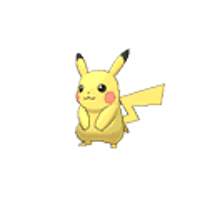

## Pokémon Biological Report

**thought**
1.  **Analyze the Image:** The image displays a small, yellow, creature with a distinct, stylized appearance.
2.  **Physical Features:**
    *   **Body Shape:** Small, rounded, and somewhat stout/chubby.
    *   **Coloration:** Predominantly bright yellow.
    *   **Appendages:** It possesses two prominent, upright, pointed ears. It has a long, thin appendage extending from its body (a tail).
    *   **Facial Features:** Simple, large eyes, and a small, pinkish/reddish patch on its body (likely on the cheek or belly).
    *   **Overall Impression:** The design is highly stylized, characteristic of digital media, but suggests a small, perhaps non-aggressive creature.
3.  **Elemental Affinities (Inference based on common Pokémon tropes):** Since the color is yellow, common elemental associations are Grass or Electric. Given the general, soft appearance, Grass is a strong candidate.
4.  **Behavioral Clues (Inference):** The small size suggests it 

In [23]:
from unsloth import FastModel
import torch
from PIL import Image
import os

model, tokenizer = FastModel.from_pretrained(
    model_name = "/kaggle/working/gemma_4_model",
    max_seq_length = 2048,
    load_in_4bit = True,
)
FastModel.for_inference(model) 


system_instruction = (
    "You are an expert Pokémon Biologist. Analyze the provided image and generate "
    "a complete biological report. Structure your thinking inside the 'thought' block, "
    "describing its physical features, elemental affinities, and behavioral clues. "
    "Then, output the definitive report including Name, Type, and a brief description."
)


test_image_path = "/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/pikachu.png"

test_image = Image.open(test_image_path)

messages = [{
    "role": "user",
    "content": [
        {"type": "image", "image": test_image},
        {"type": "text", "text": system_instruction}
    ]
}]

from transformers import TextStreamer

inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True,
    return_tensors = "pt",
    tokenize = True,
    return_dict = True,
).to("cuda")

print(f"🔬 --- Pokémon Biological Analysis --- 🔬\n")

display(test_image.resize((200, 200))) 

_ = model.generate(
    **inputs,
    max_new_tokens = 1024,
    use_cache = True,
    temperature = 0.7,
    top_p = 0.9,
    streamer = TextStreamer(tokenizer, skip_prompt = True),
)

# Checkpoint Saving: Saving the fine-tuned adapters and configuration files.

In [24]:
model.save_pretrained("gemma_4_model") 
tokenizer.save_pretrained("gemma_4_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['gemma_4_model/processor_config.json']